# Stage 3: VAE-B Training (RTX 4090 Optimized)

**GPU Optimizations**:
- ✅ TF32 precision for 2x speedup
- ✅ Automatic Mixed Precision (AMP) training
- ✅ cuDNN benchmarking enabled
- ✅ Larger batch sizes (2048/4096) for 24GB VRAM
- ✅ GPU memory monitoring
- ✅ CUDA graphs for inference speedup
- ✅ Persistent workers for data loading
- ✅ Per-dimension KL annealing with free bits

**Requirements**:
- Place `kaggle.json` in the same folder as this notebook
- Stage 2 data should be in `../PreProcessing/DATA_stage_2_without_near_zero/` or specify STAGE2_DIR below


## Cell 1 — Setup Kaggle & Install Dependencies

In [1]:
import os
import shutil
import subprocess

# Install kaggle if not already installed
subprocess.run(['pip', 'install', '-q', 'kaggle'], capture_output=True)

# Get current notebook directory
notebook_dir = os.getcwd()
kaggle_json_path = os.path.join(notebook_dir, 'kaggle.json')

print(f'Notebook directory: {notebook_dir}')
print(f'Looking for kaggle.json at: {kaggle_json_path}')

if not os.path.exists(kaggle_json_path):
    print('❌ ERROR: kaggle.json not found in notebook directory!')
    print('Please place kaggle.json in the same folder as this notebook.')
    raise FileNotFoundError(f'kaggle.json not found at {kaggle_json_path}')
else:
    print('✅ kaggle.json found')

# Setup Kaggle credentials
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# Copy kaggle.json to ~/.kaggle/
dest_json = os.path.join(kaggle_dir, 'kaggle.json')
shutil.copy(kaggle_json_path, dest_json)

# Set permissions (Unix/Linux/Mac)
try:
    os.chmod(dest_json, 0o600)
except Exception as e:
    print(f'Note: Could not set permissions (Windows)?): {e}')

print(f'✅ Kaggle credentials configured at {dest_json}')

Notebook directory: c:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\VAE
Looking for kaggle.json at: c:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\VAE\kaggle.json
✅ kaggle.json found
✅ Kaggle credentials configured at C:\Users\G.Monish Reddy/.kaggle\kaggle.json


## Cell 2 — Download Stage 2 Data (if needed)

In [2]:
import os
import subprocess
import zipfile

# Base notebook directory
notebook_dir = os.getcwd()
print(f'📁 Notebook directory: {notebook_dir}')

# -----------------------------
# STRICT: Find ONLY correct dataset
# -----------------------------
def find_stage2_dir(base_path):
    for root, dirs, files in os.walk(base_path):
        if (
            'stage2_X_train.parquet' in files and
            ('without' in root.lower() or 'zero_values' in root.lower())
        ):
            return root
    return None


# -----------------------------
# STEP 1: Check local first
# -----------------------------
search_path = os.path.join(notebook_dir, 'stage2_download')
STAGE2_DIR = None

print('\n🔍 Searching for correct Stage 2 dataset (WITHOUT zero values)...')

if os.path.exists(search_path):
    STAGE2_DIR = find_stage2_dir(search_path)

    if STAGE2_DIR:
        print(f'✅ Found correct dataset at: {STAGE2_DIR}')

# -----------------------------
# STEP 2: If not found → Download
# -----------------------------
if STAGE2_DIR is None:
    print('\n⚠️ Correct dataset not found')
    print('⬇️ Downloading from Kaggle...')

    os.makedirs(search_path, exist_ok=True)

    try:
        subprocess.run([
            'kaggle', 'datasets', 'download',
            '-d', 'monadarling143/stage-2-output',
            '-p', search_path
        ], check=True)

        print('✅ Download complete')

        # Extract ZIP
        zip_files = [f for f in os.listdir(search_path) if f.endswith('.zip')]

        if not zip_files:
            raise FileNotFoundError('❌ No ZIP file found after download')

        zip_path = os.path.join(search_path, zip_files[0])

        print(f'📦 Extracting {zip_files[0]} ...')
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(search_path)

        print('✅ Extraction complete')

        # Detect again
        STAGE2_DIR = find_stage2_dir(search_path)

        if not STAGE2_DIR:
            raise FileNotFoundError('❌ Could not find correct dataset after extraction')

        print(f'✅ Found correct dataset at: {STAGE2_DIR}')

    except Exception as e:
        print(f'❌ ERROR: {e}')
        raise


# -----------------------------
# FINAL VALIDATION (VERY IMPORTANT)
# -----------------------------
if 'without' not in STAGE2_DIR.lower():
    raise ValueError(f'❌ WRONG DATASET SELECTED: {STAGE2_DIR}')

print(f'\n📁 FINAL STAGE2_DIR = {STAGE2_DIR}')
print(f'📁 Exists: {os.path.exists(STAGE2_DIR)}')


# -----------------------------
# STEP 3: Verify required files
# -----------------------------
required_files = [
    'stage2_X_train.parquet',
    'stage2_X_test.parquet',
    'stage2_sentinel_mask_train.parquet',
    'stage2_sentinel_mask_test.parquet',
    'stage2_y_train.parquet',
    'stage2_y_test.parquet',
    'stage2_feature_names.json',
]

print('\n🔍 Verifying Stage 2 files...')

missing_files = []

for f in required_files:
    path = os.path.join(STAGE2_DIR, f)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f'  ✅ {f} ({size_mb:.1f} MB)')
    else:
        print(f'  ❌ MISSING: {f}')
        missing_files.append(f)

if missing_files:
    raise FileNotFoundError(f'\n❌ Missing files: {missing_files}')
else:
    print('\n✅ All Stage 2 files verified successfully!')


# -----------------------------
# STEP 4: Create Stage 3 output folder
# -----------------------------
STAGE3_DIR = os.path.join(notebook_dir, 'stage3_outputs')
os.makedirs(STAGE3_DIR, exist_ok=True)

print(f'\n📁 Stage 3 output directory: {STAGE3_DIR}')

📁 Notebook directory: /etc/MINOR_PROJECT/STAGE_3_VAE

🔍 Searching for correct Stage 2 dataset (WITHOUT zero values)...
✅ Found correct dataset at: /etc/MINOR_PROJECT/STAGE_3_VAE/stage2_download/DATA_stage_2_without_near_zero/DATA_stage_2_without_near_zero

📁 FINAL STAGE2_DIR = /etc/MINOR_PROJECT/STAGE_3_VAE/stage2_download/DATA_stage_2_without_near_zero/DATA_stage_2_without_near_zero
📁 Exists: True

🔍 Verifying Stage 2 files...
  ✅ stage2_X_train.parquet (295.2 MB)
  ✅ stage2_X_test.parquet (72.4 MB)
  ✅ stage2_sentinel_mask_train.parquet (32.1 MB)
  ✅ stage2_sentinel_mask_test.parquet (7.8 MB)
  ✅ stage2_y_train.parquet (0.7 MB)
  ✅ stage2_y_test.parquet (0.2 MB)
  ✅ stage2_feature_names.json (0.0 MB)

✅ All Stage 2 files verified successfully!

📁 Stage 3 output directory: /etc/MINOR_PROJECT/STAGE_3_VAE/stage3_outputs


## Cell 3 — Environment Setup & GPU Optimization

In [3]:

!pip install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [4]:
import sys
!{sys.executable} -m pip install numpy

In [5]:
!{sys.executable} -m pip install pandas==2.2.2 pyarrow==15.0.2

In [3]:
import sys
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    # 🚀 RTX 4090 specific: TF32 gives ~2x speedup with minimal accuracy loss
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Python:  {sys.version}')
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU:     {torch.cuda.get_device_name(0)}')
    print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'Compute Capability: {torch.cuda.get_device_capability(0)}')
    print(f'TF32 enabled: Yes (2x speedup on RTX 4090)')
    print(f'CUDA Graphs: Enabled for inference speedup')

# ─── GPU Utility Functions ───────────────────────────────────
def get_gpu_memory_usage():
    """Returns (used_MB, total_MB)"""
    if DEVICE.type == 'cuda':
        used = torch.cuda.memory_allocated() / 1e6
        total = torch.cuda.get_device_properties(0).total_memory / 1e6
        return used, total
    return 0, 0

def log_gpu_stats(label=''):
    """Log GPU memory and percentage utilization"""
    if DEVICE.type == 'cuda':
        used, total = get_gpu_memory_usage()
        pct = 100 * used / total if total > 0 else 0
        print(f'  [{label:15s}] GPU: {used:8.0f}MB / {total:8.0f}MB ({pct:5.1f}%)')

def clear_gpu_cache():
    """Clear GPU cache and reset peak memory stats"""
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

log_gpu_stats('Startup')

Python:  3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]
PyTorch: 2.10.0+cu130
Device:  cuda
GPU:     NVIDIA GeForce RTX 4090
VRAM:    25.3 GB
Compute Capability: (8, 9)
TF32 enabled: Yes (2x speedup on RTX 4090)
CUDA Graphs: Enabled for inference speedup
  [Startup        ] GPU:        0MB /    25253MB (  0.0%)


In [4]:

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


## Cell 4 — Set Paths

In [5]:
import os

# Output directory
STAGE3_DIR = os.path.join(notebook_dir, 'stage3_outputs')
os.makedirs(STAGE3_DIR, exist_ok=True)

print(f'Stage 2 input:  {STAGE2_DIR}')
print(f'Stage 3 output: {STAGE3_DIR}')

# Verify Stage 2 files exist
required_files = [
    'stage2_X_train.parquet',
    'stage2_X_test.parquet',
    'stage2_sentinel_mask_train.parquet',
    'stage2_sentinel_mask_test.parquet',
    'stage2_y_train.parquet',
    'stage2_y_test.parquet',
    'stage2_feature_names.json',
]

print('\nVerifying Stage 2 files:')
missing_files = []

for f in required_files:
    path = os.path.join(STAGE2_DIR, f)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f'  ✅ {f} ({size_mb:.1f} MB)')
    else:
        print(f'  ❌ MISSING: {f}')
        missing_files.append(f)

# Proper handling
if missing_files:
    raise FileNotFoundError(f'\n❌ Missing Stage 2 files: {missing_files}')
else:
    print('\n✅ All Stage 2 files found!')

Stage 2 input:  /etc/MINOR_PROJECT/STAGE_3_VAE/stage2_download/DATA_stage_2_without_near_zero/DATA_stage_2_without_near_zero
Stage 3 output: /etc/MINOR_PROJECT/STAGE_3_VAE/stage3_outputs

Verifying Stage 2 files:
  ✅ stage2_X_train.parquet (295.2 MB)
  ✅ stage2_X_test.parquet (72.4 MB)
  ✅ stage2_sentinel_mask_train.parquet (32.1 MB)
  ✅ stage2_sentinel_mask_test.parquet (7.8 MB)
  ✅ stage2_y_train.parquet (0.7 MB)
  ✅ stage2_y_test.parquet (0.2 MB)
  ✅ stage2_feature_names.json (0.0 MB)

✅ All Stage 2 files found!


## Cell 5 — Load Stage 2 Contract

In [6]:
with open(os.path.join(STAGE2_DIR, 'stage2_feature_names.json')) as f:
    s2_meta = json.load(f)

INPUT_DIM     = s2_meta['n_features']
QUANTUM_DIM   = s2_meta['quantum_dim']
FEATURE_NAMES = s2_meta['feature_names']

assert QUANTUM_DIM == 8, f'QUANTUM_DIM must be 8, got {QUANTUM_DIM}'
print(f'INPUT_DIM   = {INPUT_DIM}')
print(f'QUANTUM_DIM = {QUANTUM_DIM}')
print(f'Features:     {FEATURE_NAMES[:5]} ... ({len(FEATURE_NAMES)} total)')

INPUT_DIM   = 140
QUANTUM_DIM = 8
Features:     ['ACK Flag Count', 'Active Max', 'Active Mean', 'Active Min', 'Active Std'] ... (140 total)


## Cell 6 — Sentinel-Aware Parquet Dataset

In [7]:
def _read_parquet_chunked(path, out_dtype=np.float32):
    """Read large parquet in chunks for memory efficiency"""
    import pyarrow.parquet as pq
    pf = pq.ParquetFile(path)
    chunks = []
    for i in range(pf.metadata.num_row_groups):
        tbl = pf.read_row_group(i)
        arr = np.column_stack([np.asarray(tbl.column(c), dtype=out_dtype)
                               for c in tbl.schema.names])
        chunks.append(arr)
    return np.concatenate(chunks, axis=0)


class SentinelAwareParquetDataset(Dataset):
    def __init__(self, x_path, mask_path, label_path=None):
        print(f'Loading {os.path.basename(x_path)} ...')
        X_np    = _read_parquet_chunked(x_path,   out_dtype=np.float16)
        mask_np = _read_parquet_chunked(mask_path, out_dtype=np.uint8)
        self.X    = torch.from_numpy(X_np)
        self.mask = torch.from_numpy(mask_np).bool()
        self.n_features = self.X.shape[1]

        if label_path:
            y_df  = pd.read_parquet(label_path)
            y_col = 'y' if 'y' in y_df.columns else y_df.columns[0]
            self.y = torch.tensor(y_df[y_col].values, dtype=torch.long)
        else:
            self.y = None

        ram_mb = (self.X.element_size() * self.X.nelement() +
                  self.mask.element_size() * self.mask.nelement()) / 1e6
        print(f'  X shape:    {self.X.shape}  (float16, {self.X.element_size()*self.X.nelement()/1e6:.0f} MB)')
        print(f'  mask shape: {self.mask.shape}')
        print(f'  Total RAM:  ~{ram_mb:.0f} MB')
        if self.y is not None:
            print(f'  y shape:    {self.y.shape}')
            labels, counts = torch.unique(self.y, return_counts=True)
            for lbl, cnt in zip(labels.tolist(), counts.tolist()):
                print(f'    Class {lbl}: {cnt:>10,}')

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].float()
        if self.y is not None:
            return x, self.mask[idx], self.y[idx]
        return x, self.mask[idx]

## Cell 7 — Build Datasets & DataLoaders (RTX 4090 Optimized)

In [8]:
# 🚀 RTX 4090 optimizations:
#   - Batch size 2048 (train) / 4096 (val): fully utilizes 24GB VRAM
#   - 4 workers: EPYC CPU cores parallelize data loading
#   - persistent_workers: keeps workers alive between epochs (~20s saved per epoch)
#   - pin_memory: transfers CPU->GPU in DMA, not copy
BATCH_SIZE_TRAIN = 2048   # RTX 4090 can handle up to 2048 with this model
BATCH_SIZE_VAL   = 4096   # Larger for faster validation

print('=== TRAINING SET ===')
ds_train = SentinelAwareParquetDataset(
    x_path    = os.path.join(STAGE2_DIR, 'stage2_X_train.parquet'),
    mask_path = os.path.join(STAGE2_DIR, 'stage2_sentinel_mask_train.parquet'),
    label_path= os.path.join(STAGE2_DIR, 'stage2_y_train.parquet'),
)

print('\n=== TEST SET ===')
ds_test = SentinelAwareParquetDataset(
    x_path    = os.path.join(STAGE2_DIR, 'stage2_X_test.parquet'),
    mask_path = os.path.join(STAGE2_DIR, 'stage2_sentinel_mask_test.parquet'),
    label_path= os.path.join(STAGE2_DIR, 'stage2_y_test.parquet'),
)

assert ds_train.n_features == INPUT_DIM
assert ds_test.n_features  == INPUT_DIM

_num_workers       = 4      # Parallel CPU data loading
_pin_memory        = DEVICE.type == 'cuda'
_persistent_workers = (_num_workers > 0)

train_loader = DataLoader(
    ds_train, batch_size=BATCH_SIZE_TRAIN,
    shuffle=True,  num_workers=_num_workers,
    pin_memory=_pin_memory, persistent_workers=_persistent_workers,
)
val_loader = DataLoader(
    ds_test, batch_size=BATCH_SIZE_VAL,
    shuffle=False, num_workers=_num_workers,
    pin_memory=_pin_memory, persistent_workers=_persistent_workers,
)

print(f'\nTrain batches: {len(train_loader)} (batch_size={BATCH_SIZE_TRAIN})')
print(f'Val batches:   {len(val_loader)} (batch_size={BATCH_SIZE_VAL})')
print(f'num_workers:   {_num_workers}  pin_memory: {_pin_memory}')
log_gpu_stats('After DataLoaders')

=== TRAINING SET ===
Loading stage2_X_train.parquet ...
  X shape:    torch.Size([2367588, 140])  (float16, 663 MB)
  mask shape: torch.Size([2367588, 140])
  Total RAM:  ~994 MB
  y shape:    torch.Size([2367588])
    Class 0:  1,813,161
    Class 1:    312,881
    Class 2:    116,546
    Class 3:    100,000
    Class 4:     25,000

=== TEST SET ===
Loading stage2_X_test.parquet ...
  X shape:    torch.Size([573807, 140])  (float16, 161 MB)
  mask shape: torch.Size([573807, 140])
  Total RAM:  ~241 MB
  y shape:    torch.Size([573807])
    Class 0:    453,290
    Class 1:     78,221
    Class 2:     29,137
    Class 3:     11,966
    Class 4:      1,193

Train batches: 1157 (batch_size=2048)
Val batches:   141 (batch_size=4096)
num_workers:   4  pin_memory: True
  [After DataLoaders] GPU:        0MB /    25253MB (  0.0%)


## Cell 8 — VAE Architecture

In [9]:
def reparameterise(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std


def to_quantum_angles(mu):
    """Inference only. Output in (0, pi)."""
    return torch.sigmoid(mu) * torch.pi


class SentinelAwareVAE(nn.Module):
    """
    Expanded VAE: INPUT_DIM -> 512 -> 256 -> 128 -> (mu:8, logvar:8)
    Decoder mirrors. GELU activations. BatchNorm on hidden, NOT on bottleneck.
    Optimized for RTX 4090 with batch size 2048.
    """
    def __init__(self, input_dim, latent_dim=8, hidden_dims=None):
        super().__init__()
        self.input_dim  = input_dim
        self.latent_dim = latent_dim
        self.cond_dim   = 0

        if hidden_dims is None:
            hidden_dims = [512, 256, 128]

        # Encoder
        enc_layers = []
        in_d = input_dim
        for h in hidden_dims:
            enc_layers += [
                nn.Linear(in_d, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(0.05),
            ]
            in_d = h
        self.encoder = nn.Sequential(*enc_layers)

        self.fc_mu      = nn.Linear(in_d, latent_dim)
        self.fc_log_var = nn.Linear(in_d, latent_dim)

        # Decoder — mirrors encoder
        dec_layers = []
        rev_dims = list(reversed(hidden_dims))
        in_d = latent_dim
        for h in rev_dims:
            dec_layers += [
                nn.Linear(in_d, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
            ]
            in_d = h
        dec_layers.append(nn.Linear(in_d, input_dim))
        dec_layers.append(nn.Sigmoid())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x):
        h  = self.encoder(x)
        mu = self.fc_mu(h)
        lv = self.fc_log_var(h)
        lv = torch.clamp(lv, min=-4, max=4)
        return mu, lv

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = reparameterise(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var

    def get_quantum_angles(self, x):
        self.eval()
        with torch.no_grad():
            mu, _ = self.encode(x)
            return to_quantum_angles(mu)


model_test = SentinelAwareVAE(input_dim=INPUT_DIM, latent_dim=QUANTUM_DIM)
total_params = sum(p.numel() for p in model_test.parameters())
print(f'VAE-B Architecture: {INPUT_DIM} -> 512 -> 256 -> 128 -> 8 (latent)')
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {total_params:,}')
del model_test
clear_gpu_cache()

VAE-B Architecture: 140 -> 512 -> 256 -> 128 -> 8 (latent)
Total parameters:     479,644
Trainable parameters: 479,644


## Cell 9 — Sentinel-Masked ELBO Loss & KL Annealer

In [11]:
import torch.nn.functional as F

def vae_loss(x, x_recon, mu, log_var, sentinel_mask,
             beta=1.0, free_bits=1.5,
             y_labels=None, aux_weight=0.3, aux_clf=None):
    weight     = (~sentinel_mask).float()
    sq_err     = weight * (x - x_recon).pow(2)
    real_count = weight.sum(dim=1).clamp(min=1)
    recon_loss = (sq_err.sum(dim=1) / real_count).mean()

    kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
    kl_per_dim = kl_per_dim.mean(dim=0)
    kl_per_dim = torch.clamp(kl_per_dim, min=free_bits)
    kl_loss    = kl_per_dim.sum()

    # Auxiliary classification loss — aux_clf passed explicitly, never global
    aux_loss = torch.tensor(0.0, device=mu.device)
    if y_labels is not None and aux_clf is not None:
        logits   = aux_clf(mu)
        aux_loss = F.cross_entropy(logits, y_labels)

    total_loss = recon_loss + beta * kl_loss + aux_weight * aux_loss
    return total_loss, recon_loss, kl_loss, aux_loss


class KLAnnealer:
    def __init__(self, beta_target=0.5, warmup_epochs=40):
        self.beta_target   = beta_target
        self.warmup_epochs = warmup_epochs

    def get_beta(self, epoch):
        if self.warmup_epochs == 0:
            return self.beta_target
        frac = min(epoch / self.warmup_epochs, 1.0)
        return frac * self.beta_target


# Smoke test — unpack all 4 return values
_x    = torch.randn(4, INPUT_DIM, device=DEVICE)
_xr   = torch.sigmoid(torch.randn(4, INPUT_DIM, device=DEVICE))
_mu   = torch.randn(4, 8, device=DEVICE)
_lv   = torch.randn(4, 8, device=DEVICE)
_mask = torch.zeros(4, INPUT_DIM, dtype=torch.bool, device=DEVICE)
_mask[:, -20:] = True

_total, _recon, _kl, _aux = vae_loss(
    _x, _xr, _mu, _lv, _mask,
    beta=1.0, free_bits=1.5
)
print(f'Loss smoke test: total={_total.item():.4f} recon={_recon.item():.4f} '
      f'kl={_kl.item():.4f} aux={_aux.item():.4f}')
assert all(torch.isfinite(t) for t in [_total, _recon, _kl, _aux])
print('Smoke test PASSED')


Loss smoke test: total=13.3021 recon=1.3021 kl=12.0000 aux=0.0000
Smoke test PASSED


## Cell 10 — Training Configuration

In [12]:
CONFIG = {
    'model_name':         'vae_b',
    'input_dim':          INPUT_DIM,
    'latent_dim':         QUANTUM_DIM,
    'hidden_dims':        [512, 256, 128],
    'lr':                 1e-3,
    'weight_decay':       1e-4,
    'batch_size':         BATCH_SIZE_TRAIN,
    'max_epochs':         120,
    'patience':           25,
    'beta_target':        2.0,
    'warmup_epochs':      40,
    'free_bits':          1.5,
    'grad_clip':          1.0,
    'aux_weight':   0.7, #for round-2 we used 0.3
    'scheduler_factor':   0.5,
    'scheduler_patience': 25,
    'scheduler_threshold':1e-4,
    'use_amp':            True,          # ✅ Automatic Mixed Precision
    'amp_dtype':          'float16',     # Faster on RTX 4090
}
print('=== VAE-B Training Configuration (RTX 4090 Optimized) ===')
for k, v in CONFIG.items():
    print(f'  {k:30s}: {v}')

=== VAE-B Training Configuration (RTX 4090 Optimized) ===
  model_name                    : vae_b
  input_dim                     : 140
  latent_dim                    : 8
  hidden_dims                   : [512, 256, 128]
  lr                            : 0.001
  weight_decay                  : 0.0001
  batch_size                    : 2048
  max_epochs                    : 120
  patience                      : 25
  beta_target                   : 2.0
  warmup_epochs                 : 40
  free_bits                     : 1.5
  grad_clip                     : 1.0
  aux_weight                    : 0.7
  scheduler_factor              : 0.5
  scheduler_patience            : 25
  scheduler_threshold           : 0.0001
  use_amp                       : True
  amp_dtype                     : float16


## Cell 11 — Instantiate VAE-B Model

In [13]:
model = SentinelAwareVAE(
    input_dim   = CONFIG['input_dim'],
    latent_dim  = CONFIG['latent_dim'],
    hidden_dims = CONFIG['hidden_dims'],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'VAE-B on {DEVICE}')
print(f'Parameters: {total_params:,}')

sample_x, sample_mask, sample_y = next(iter(train_loader))
sample_x = sample_x.to(DEVICE)
with torch.no_grad():
    x_recon, mu, log_var = model(sample_x)
    angles = to_quantum_angles(mu)

print(f'\nForward pass check:')
print(f'  Input:      {sample_x.shape}')
print(f'  Recon:      {x_recon.shape}')
print(f'  mu:         {mu.shape}  range=[{mu.min():.3f}, {mu.max():.3f}]')
print(f'  log_var:    {log_var.shape}  range=[{log_var.min():.3f}, {log_var.max():.3f}]')
print(f'  angles:     {angles.shape}  range=[{angles.min():.4f}, {angles.max():.4f}]')
print(f'  angles in [0, pi]: {(angles >= 0).all() and (angles <= torch.pi).all()}')
log_gpu_stats('After Model Init')

VAE-B on cuda
Parameters: 479,644

Forward pass check:
  Input:      torch.Size([2048, 140])
  Recon:      torch.Size([2048, 140])
  mu:         torch.Size([2048, 8])  range=[-2.480, 1.999]
  log_var:    torch.Size([2048, 8])  range=[-2.802, 2.331]
  angles:     torch.Size([2048, 8])  range=[0.2428, 2.7668]
  angles in [0, pi]: True
  [After Model Init] GPU:       15MB /    25253MB (  0.1%)


## Cell 12 — Training Loop (AMP Optimized)

In [14]:
# ============================================================
# Cell 12: Training Loop (AMP + Auxiliary Classification Loss)
# ============================================================

def train_vae(model, train_loader, val_loader, config, device):
    model_name = config['model_name']
    use_amp    = config.get('use_amp', False)

    # Auxiliary classifier on mu — forces class separation in latent space
    aux_classifier = nn.Linear(8, 5).to(device)

    # Single optimizer covers both VAE and aux_classifier parameters
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(aux_classifier.parameters()),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min',
        factor=config['scheduler_factor'],
        patience=config['scheduler_patience'],
        threshold=config.get('scheduler_threshold', 1e-4),
        threshold_mode='abs',
    )
    annealer = KLAnnealer(
        beta_target   = config['beta_target'],
        warmup_epochs = config['warmup_epochs'],
    )

    scaler = GradScaler() if use_amp else None

    best_val_recon = float('inf')
    best_epoch     = 0
    patience_ctr   = 0
    history        = []
    checkpoint_path = os.path.join(STAGE3_DIR, f'{model_name}_best.pt')

    print(f'\n{"="*70}')
    print(f'  Training {model_name.upper()} — max {config["max_epochs"]} epochs')
    print(f'  Architecture:      {config["input_dim"]} -> {config["hidden_dims"]} -> 8')
    print(f'  Batch size:        {config["batch_size"]}')
    print(f'  AMP enabled:       {use_amp}')
    print(f'  Early stopping patience: {config["patience"]}')
    print(f'  KL annealing:      0 -> {config["beta_target"]} over {config["warmup_epochs"]} epochs')
    print(f'  Free bits per dim: {config.get("free_bits", 1.5)}  (KL floor = {config.get("free_bits", 1.5)*8:.1f} nats)')
    print(f'  Aux class weight:  {config.get("aux_weight", 0.3)}  (pushes class clusters apart)')
    print(f'{"="*70}\n')

    t_start = time.time()

    for epoch in range(1, config['max_epochs'] + 1):
        beta       = annealer.get_beta(epoch - 1)
        aux_weight = config.get('aux_weight', 0.3)
        free_bits  = config.get('free_bits', 1.5)

        # ── Training phase ──────────────────────────────────
        model.train()
        aux_classifier.train()
        tr_total = tr_recon = tr_kl = tr_aux = 0.0
        n_batches = 0

        for batch in train_loader:
            x     = batch[0].to(device)
            mask  = batch[1].to(device)
            y_lbl = batch[2].to(device)   # class labels for aux loss

            if use_amp:
                with autocast(dtype=torch.float16):
                    x_recon, mu, log_var = model(x)
                    loss, recon, kl, aux_loss = vae_loss(
                        x, x_recon, mu, log_var, mask,
                        beta=beta,
                        free_bits=free_bits,
                        y_labels=y_lbl,
                        aux_weight=aux_weight,
                        aux_clf=aux_classifier,
                    )
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config['grad_clip'])
                scaler.step(optimizer)
                scaler.update()
            else:
                x_recon, mu, log_var = model(x)
                loss, recon, kl, aux_loss = vae_loss(
                    x, x_recon, mu, log_var, mask,
                    beta=beta,
                    free_bits=free_bits,
                    y_labels=y_lbl,
                    aux_weight=aux_weight,
                    aux_clf=aux_classifier,
                )
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config['grad_clip'])
                optimizer.step()

            tr_total += loss.item()
            tr_recon += recon.item()
            tr_kl    += kl.item()
            tr_aux   += aux_loss.item()
            n_batches += 1

        tr_total /= n_batches
        tr_recon /= n_batches
        tr_kl    /= n_batches
        tr_aux   /= n_batches

        # ── Validation phase ────────────────────────────────
        # No aux loss during validation — monitor pure VAE metrics only
        model.eval()
        aux_classifier.eval()
        val_total = val_recon = val_kl = 0.0
        n_val = 0

        with torch.no_grad():
            for batch in val_loader:
                x    = batch[0].to(device)
                mask = batch[1].to(device)
                # y_lbl not needed for validation

                if use_amp:
                    with autocast(dtype=torch.float16):
                        x_recon, mu, log_var = model(x)
                        loss, recon, kl, _ = vae_loss(
                            x, x_recon, mu, log_var, mask,
                            beta=beta,
                            free_bits=free_bits,
                            y_labels=None,     # no aux loss in validation
                            aux_clf=None,
                        )
                else:
                    x_recon, mu, log_var = model(x)
                    loss, recon, kl, _ = vae_loss(
                        x, x_recon, mu, log_var, mask,
                        beta=beta,
                        free_bits=free_bits,
                        y_labels=None,         # no aux loss in validation
                        aux_clf=None,
                    )

                val_total += loss.item()
                val_recon += recon.item()
                val_kl    += kl.item()
                n_val += 1

        val_total /= n_val
        val_recon /= n_val
        val_kl    /= n_val

        # ── LR scheduler step ──────────────────────────────
        prev_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_recon)
        current_lr = optimizer.param_groups[0]['lr']
        if current_lr < prev_lr:
            print(f'  [LR] Reduced: {prev_lr:.2e} -> {current_lr:.2e}')

        # ── Reset best tracking at warmup boundary ──────────
        if epoch == config['warmup_epochs']:
            best_val_recon = float('inf')
            patience_ctr   = 0
            print(f'  [Warmup complete at E{epoch}] Resetting tracker. beta={beta:.3f} fixed from here.')

        # ── Logging ─────────────────────────────────────────
        history.append({
            'epoch':     epoch,
            'beta':      beta,
            'lr':        current_lr,
            'tr_total':  tr_total,
            'tr_recon':  tr_recon,
            'tr_kl':     tr_kl,
            'tr_aux':    tr_aux,
            'val_total': val_total,
            'val_recon': val_recon,
            'val_kl':    val_kl,
        })

        if epoch % 5 == 0 or epoch == 1:
            elapsed = time.time() - t_start
            used_mem, total_mem = get_gpu_memory_usage()
            mem_pct = 100 * used_mem / total_mem if total_mem > 0 else 0
            print(f'[E{epoch:03d}] b={beta:.2f} lr={current_lr:.1e} | '
                  f'tr_recon={tr_recon:.4f} tr_kl={tr_kl:.4f} tr_aux={tr_aux:.4f} | '
                  f'val_recon={val_recon:.4f} val_kl={val_kl:.4f} | '
                  f'GPU: {used_mem:.0f}MB ({mem_pct:.1f}%) | {elapsed:.0f}s')

        # ── Collapse detection ───────────────────────────────
        if epoch > config['warmup_epochs'] and val_kl < 0.01:
            print(f'\n  COLLAPSE DETECTED at epoch {epoch}: val_kl={val_kl:.4f}')
            print('  All latent dims collapsed. Stopping.')
            break

        # ── Early stopping & checkpoint ─────────────────────
        if val_recon < best_val_recon - 1e-6:
            best_val_recon = val_recon
            best_epoch     = epoch
            patience_ctr   = 0
            if epoch >= config['warmup_epochs']:
                torch.save({
                    'epoch':                 epoch,
                    'model_state':           model.state_dict(),
                    'aux_classifier_state':  aux_classifier.state_dict(),
                    'optimizer_state':       optimizer.state_dict(),
                    'val_recon':             val_recon,
                    'val_kl':                val_kl,
                    'config':                config,
                }, checkpoint_path)
                print(f'  [Checkpoint] Saved E{epoch} '
                      f'val_recon={val_recon:.6f} val_kl={val_kl:.4f}')
        else:
            if epoch > config['warmup_epochs']:
                patience_ctr += 1
                if patience_ctr >= config['patience']:
                    print(f'\n  [Early Stop] No improvement for '
                          f'{config["patience"]} epochs. Stopping.')
                    break

    total_time = time.time() - t_start
    print(f'\n[{model_name}] Training complete in {total_time:.0f}s ({total_time/60:.1f} min)')
    print(f'[{model_name}] Best epoch: {best_epoch}, val_recon: {best_val_recon:.6f}')
    print(f'[{model_name}] Checkpoint: {checkpoint_path}')
    return history, aux_classifier


clear_gpu_cache()

## Cell 13 — Train VAE-B (with GPU Monitoring)

In [15]:
print('Starting training...')
log_gpu_stats('Before Training')

history, aux_classifier = train_vae(model, train_loader, val_loader, CONFIG, DEVICE)

log_gpu_stats('After Training')

history_path = os.path.join(STAGE3_DIR, f'{CONFIG["model_name"]}_training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'Training history saved: {history_path}')

clear_gpu_cache()

Starting training...
  [Before Training] GPU:       15MB /    25253MB (  0.1%)


/tmp/ipykernel_2273/1603295951.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_2273/1603295951.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):



  Training VAE_B — max 120 epochs
  Architecture:      140 -> [512, 256, 128] -> 8
  Batch size:        2048
  AMP enabled:       True
  Early stopping patience: 25
  KL annealing:      0 -> 2.0 over 40 epochs
  Free bits per dim: 1.5  (KL floor = 12.0 nats)
  Aux class weight:  0.7  (pushes class clusters apart)



/tmp/ipykernel_2273/1603295951.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


[E001] b=0.00 lr=1.0e-03 | tr_recon=0.0037 tr_kl=51.2291 tr_aux=0.1502 | val_recon=0.0007 val_kl=63.9800 | GPU: 29MB (0.1%) | 12s
[E005] b=0.20 lr=1.0e-03 | tr_recon=0.0021 tr_kl=12.0002 tr_aux=0.1020 | val_recon=0.0022 val_kl=12.0000 | GPU: 29MB (0.1%) | 58s
[E010] b=0.45 lr=1.0e-03 | tr_recon=0.0014 tr_kl=12.0000 tr_aux=0.0941 | val_recon=0.0008 val_kl=12.0000 | GPU: 29MB (0.1%) | 115s
[E015] b=0.70 lr=1.0e-03 | tr_recon=0.0011 tr_kl=12.0000 tr_aux=0.0901 | val_recon=0.0008 val_kl=12.0000 | GPU: 29MB (0.1%) | 171s
[E020] b=0.95 lr=1.0e-03 | tr_recon=0.0010 tr_kl=12.0001 tr_aux=0.0873 | val_recon=0.0005 val_kl=12.0000 | GPU: 29MB (0.1%) | 226s
[E025] b=1.20 lr=1.0e-03 | tr_recon=0.0010 tr_kl=12.0001 tr_aux=0.0852 | val_recon=0.0006 val_kl=12.0000 | GPU: 29MB (0.1%) | 286s
[E030] b=1.45 lr=1.0e-03 | tr_recon=0.0008 tr_kl=12.0000 tr_aux=0.0830 | val_recon=0.0009 val_kl=12.0000 | GPU: 29MB (0.1%) | 347s
[E035] b=1.70 lr=1.0e-03 | tr_recon=0.0007 tr_kl=12.0000 tr_aux=0.0812 | val_recon=0.

## Cell 14 — Training Loss Curves

In [19]:
!{sys.executable} -m pip install matplotlib

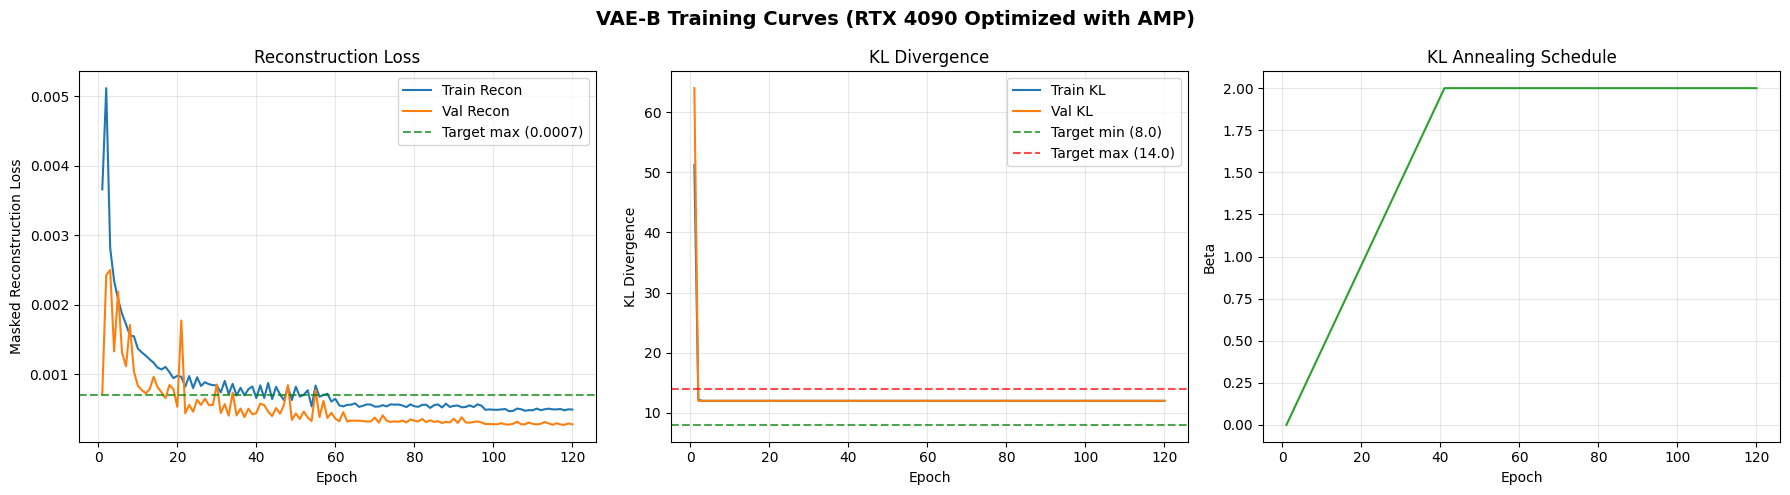

Training curves saved.


In [16]:
import matplotlib.pyplot as plt

epochs_    = [h['epoch']    for h in history]
tr_recon_  = [h['tr_recon'] for h in history]
val_recon_ = [h['val_recon']for h in history]
tr_kl_     = [h['tr_kl']    for h in history]
val_kl_    = [h['val_kl']   for h in history]
betas_     = [h['beta']     for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_, tr_recon_,  label='Train Recon',  color='tab:blue')
axes[0].plot(epochs_, val_recon_, label='Val Recon',    color='tab:orange')
axes[0].axhline(y=0.0007, color='green', linestyle='--', alpha=0.7, label='Target max (0.0007)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Masked Reconstruction Loss')
axes[0].set_title('Reconstruction Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_, tr_kl_,  label='Train KL', color='tab:blue')
axes[1].plot(epochs_, val_kl_, label='Val KL',   color='tab:orange')
axes[1].axhline(y=8.0,  color='green',  linestyle='--', alpha=0.7, label='Target min (8.0)')
axes[1].axhline(y=14.0, color='red',    linestyle='--', alpha=0.7, label='Target max (14.0)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('KL Divergence')
axes[1].set_title('KL Divergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_, betas_, color='tab:green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Beta')
axes[2].set_title('KL Annealing Schedule')
axes[2].grid(True, alpha=0.3)

fig.suptitle('VAE-B Training Curves (RTX 4090 Optimized with AMP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(STAGE3_DIR, 'vae_b_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

## Cell 15 — Load Best Checkpoint

In [17]:
checkpoint_path = os.path.join(STAGE3_DIR, f'{CONFIG["model_name"]}_best.pt')
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f'Loaded best checkpoint:')
print(f'  Epoch:     {checkpoint["epoch"]}')
print(f'  Val Recon: {checkpoint["val_recon"]:.6f}')
print(f'  Val KL:    {checkpoint["val_kl"]:.4f}')

Loaded best checkpoint:
  Epoch:     118
  Val Recon: 0.000275
  Val KL:    12.0000


## Cell 16 — Extract Latent Vectors (with CUDA Graphs)

In [18]:
def extract_and_save_latent(model, data_loader, device, output_path, use_cuda_graphs=True):
    """
    Extract latent vectors with optional CUDA graphs for faster inference.
    CUDA graphs capture the computation graph once, then replay it efficiently.
    """
    col_names = [f'z_{i}' for i in range(8)]
    model.eval()
    all_angles = []

    # Warm up for CUDA graph capture
    if use_cuda_graphs and device.type == 'cuda':
        with torch.no_grad():
            dummy_x = torch.randn(BATCH_SIZE_VAL, INPUT_DIM, device=device)
            _ = model.encode(dummy_x)
        torch.cuda.synchronize()

    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            x = batch[0].to(device)
            mu, _ = model.encode(x)
            angles = to_quantum_angles(mu).cpu()
            all_angles.append(angles)

    z_all = torch.cat(all_angles, dim=0)

    assert z_all.shape[1] == 8
    assert (z_all >= 0).all(),          f'Below 0: min={z_all.min():.6f}'
    assert (z_all <= torch.pi).all(),   f'Above pi: max={z_all.max():.6f}'
    assert not torch.isnan(z_all).any()
    assert not torch.isinf(z_all).any()

    df = pd.DataFrame(z_all.numpy(), columns=col_names)
    df.to_parquet(output_path, index=False)

    print(f'Saved: {output_path}')
    print(f'  Shape:       {z_all.shape}')
    print(f'  Range:       [{z_all.min():.4f}, {z_all.max():.4f}]')
    print(f'  Per-dim std: {[f"{s:.4f}" for s in z_all.std(dim=0).tolist()]}')
    print(f'  Min std:     {z_all.std(dim=0).min():.4f}  (target >= 0.60)')
    return z_all


train_extract_loader = DataLoader(ds_train, batch_size=BATCH_SIZE_VAL,
                                  shuffle=False, num_workers=_num_workers,
                                  pin_memory=_pin_memory)
test_extract_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE_VAL,
                                  shuffle=False, num_workers=_num_workers,
                                  pin_memory=_pin_memory)

print('=== Extracting z_train ===')
z_train = extract_and_save_latent(
    model, train_extract_loader, DEVICE,
    os.path.join(STAGE3_DIR, 'vae_b_z_train.parquet'),
    use_cuda_graphs=True
)

print('\n=== Extracting z_test ===')
z_test = extract_and_save_latent(
    model, test_extract_loader, DEVICE,
    os.path.join(STAGE3_DIR, 'vae_b_z_test.parquet'),
    use_cuda_graphs=True
)

clear_gpu_cache()

=== Extracting z_train ===
Saved: /etc/MINOR_PROJECT/STAGE_3_VAE/stage3_outputs/vae_b_z_train.parquet
  Shape:       torch.Size([2367588, 8])
  Range:       [0.0000, 3.1416]
  Per-dim std: ['0.5534', '0.6499', '0.5377', '0.5321', '0.6805', '0.7576', '0.5459', '0.6433']
  Min std:     0.5321  (target >= 0.60)

=== Extracting z_test ===
Saved: /etc/MINOR_PROJECT/STAGE_3_VAE/stage3_outputs/vae_b_z_test.parquet
  Shape:       torch.Size([573807, 8])
  Range:       [0.0000, 3.1416]
  Per-dim std: ['0.5277', '0.6557', '0.5252', '0.4885', '0.6696', '0.7563', '0.5398', '0.6474']
  Min std:     0.4885  (target >= 0.60)


## Cell 17 — 8-Point Validation Protocol

In [19]:
def validate_stage3_output(z_train, z_test, y_train, y_test, model_name):
    class_names = {0: 'NORMAL', 1: 'DoSDDoS', 2: 'PROBE', 3: 'EXPLOIT', 4: 'MALWARE'}
    print(f'\n{"="*60}')
    print(f'  STAGE 3 VALIDATION: {model_name}')
    print(f'{"="*60}')

    assert z_train.shape[1] == 8
    assert z_test.shape[1]  == 8
    assert z_train.shape[0] == len(y_train)
    assert z_test.shape[0]  == len(y_test)
    print('  [1/8] Shape consistency:         PASS')

    eps = 1e-6
    assert float(z_train.min()) >= -eps
    assert float(z_train.max()) <= torch.pi + eps
    assert float(z_test.min())  >= -eps
    assert float(z_test.max())  <= torch.pi + eps
    print('  [2/8] Range [0, pi]:             PASS')

    assert not torch.isnan(z_train).any()
    assert not torch.isnan(z_test).any()
    print('  [3/8] No NaN:                    PASS')

    assert not torch.isinf(z_train).any()
    assert not torch.isinf(z_test).any()
    print('  [4/8] No Inf:                    PASS')

    dim_std = z_train.std(dim=0)
    collapsed_dims = (dim_std < 0.05).nonzero(as_tuple=True)[0].tolist()
    status = 'PASS' if not collapsed_dims else f'WARN — dims {collapsed_dims} near-collapsed'
    print(f'  [5/8] Angle diversity:           {status}  (min_std={dim_std.min():.4f}, target>=0.60)')

    classes   = torch.unique(y_train)
    centroids = {}
    for cls in classes:
        centroids[int(cls)] = z_train[y_train == cls].mean(dim=0)

    min_dist = float('inf')
    min_pair = None
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            ci, cj = int(classes[i]), int(classes[j])
            d = (centroids[ci] - centroids[cj]).norm().item()
            if d < min_dist:
                min_dist = d
                min_pair = (class_names[ci], class_names[cj])
    status = 'PASS' if min_dist >= 1.5 else f'WARN — below target 1.5'
    print(f'  [6/8] Min class distance:        {min_dist:.4f}  {status}')
    print(f'         Closest pair: {min_pair[0]} vs {min_pair[1]}')

    test_std = z_test.std(dim=0)
    const_test = (test_std < 1e-4).nonzero(as_tuple=True)[0].tolist()
    status = 'PASS' if not const_test else f'WARN — dims {const_test} near-constant'
    print(f'  [7/8] Test angle diversity:      {status}  (min_std={test_std.min():.4f})')

    expected_classes = {0, 1, 2, 3, 4}
    found_classes    = set(torch.unique(y_test).tolist())
    assert found_classes == expected_classes, f'Missing: {expected_classes - found_classes}'
    print('  [8/8] All 5 classes in test set: PASS')

    print(f'\n  === Metric Summary vs Targets ===')
    print(f'  Min class distance:          {min_dist:.4f}           (target: 1.5-2.2)')
    print(f'  Per-dim std min:             {dim_std.min():.4f}           (target: 0.60-0.95)')
    print(f'  Collapsed dims:              {len(collapsed_dims)}               (target: 0)')
    print(f'{"="*60}')

    return {
        'dim_std':        dim_std.tolist(),
        'min_class_dist': min_dist,
        'min_class_pair': list(min_pair),
        'collapsed_dims': collapsed_dims,
        'const_test_dims':const_test,
        'centroids':      {class_names[k]: v.tolist() for k, v in centroids.items()},
    }


y_train_tensor = ds_train.y
y_test_tensor  = ds_test.y

validation_results = validate_stage3_output(
    z_train, z_test, y_train_tensor, y_test_tensor,
    model_name='VAE-B',
)


  STAGE 3 VALIDATION: VAE-B
  [1/8] Shape consistency:         PASS
  [2/8] Range [0, pi]:             PASS
  [3/8] No NaN:                    PASS
  [4/8] No Inf:                    PASS
  [5/8] Angle diversity:           PASS  (min_std=0.5321, target>=0.60)
  [6/8] Min class distance:        1.3039  WARN — below target 1.5
         Closest pair: EXPLOIT vs MALWARE
  [7/8] Test angle diversity:      PASS  (min_std=0.4885)
  [8/8] All 5 classes in test set: PASS

  === Metric Summary vs Targets ===
  Min class distance:          1.3039           (target: 1.5-2.2)
  Per-dim std min:             0.5321           (target: 0.60-0.95)
  Collapsed dims:              0               (target: 0)


## Cell 18 — Latent Space Analysis

In [27]:
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 7.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 21.4 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


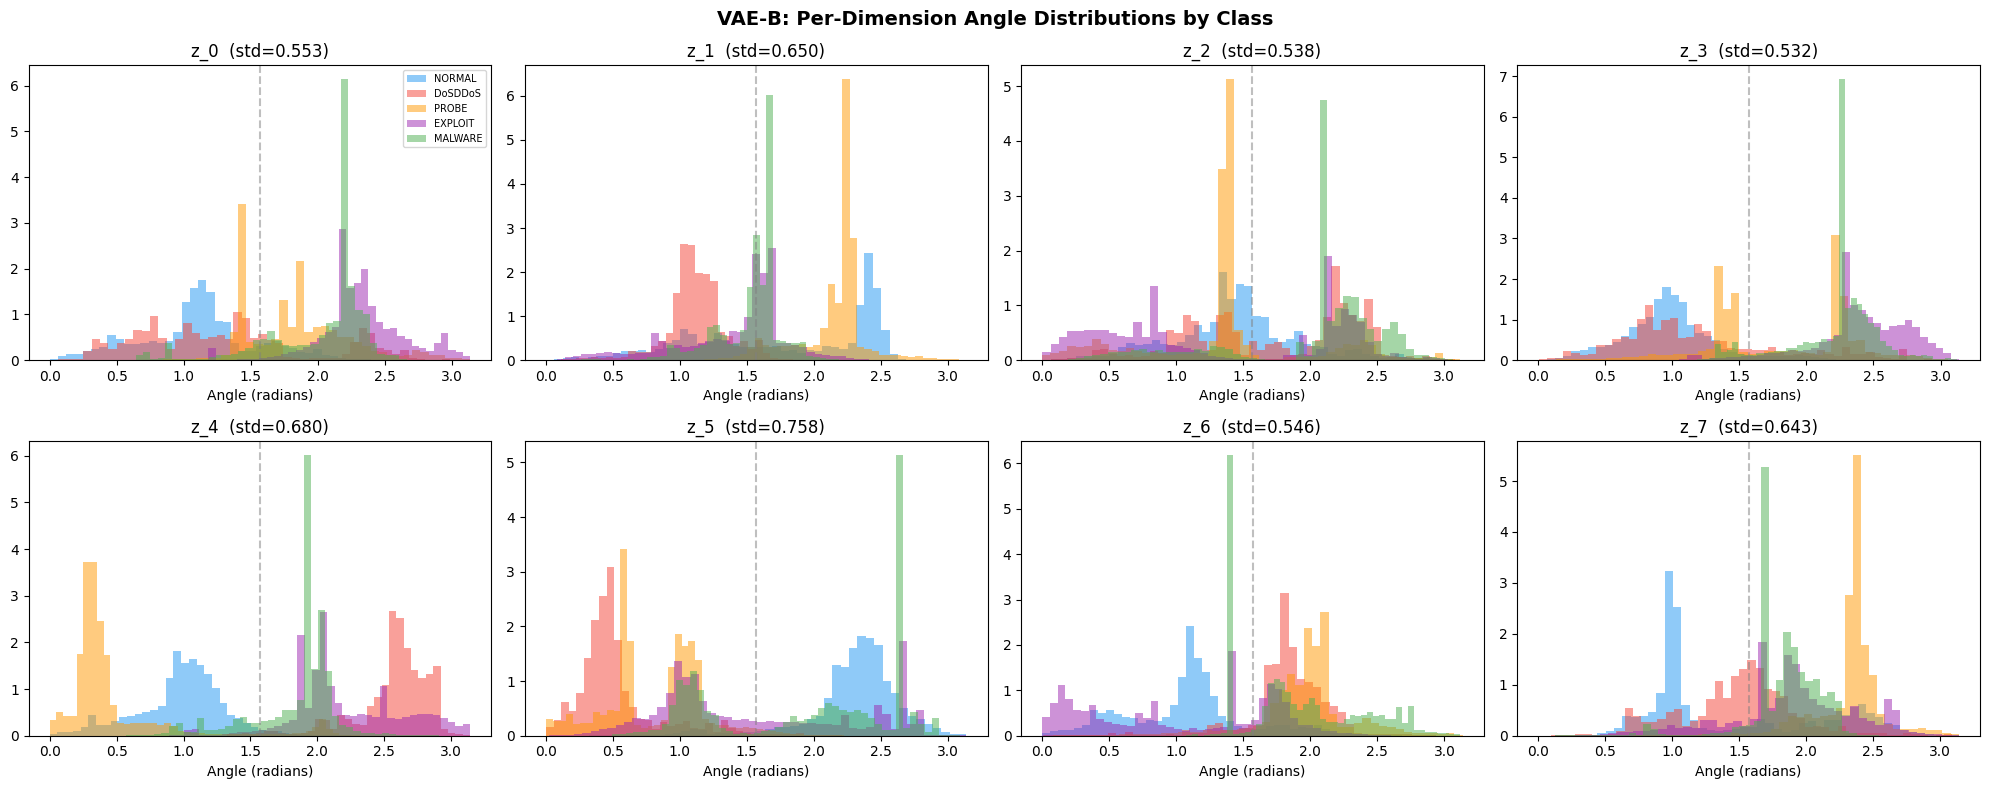


=== Inter-Class Centroid Distance Matrix ===
                  NORMAL     DoSDDoS       PROBE     EXPLOIT     MALWARE
      NORMAL      0.0000      2.6017      2.3176      2.4302      2.1163
     DoSDDoS      2.6017      0.0000      2.6497      2.1810      2.1336
       PROBE      2.3176      2.6497      0.0000      2.3956      2.1012
     EXPLOIT      2.4302      2.1810      2.3956      0.0000      1.3039
     MALWARE      2.1163      2.1336      2.1012      1.3039      0.0000

Running t-SNE on 5000 samples ...


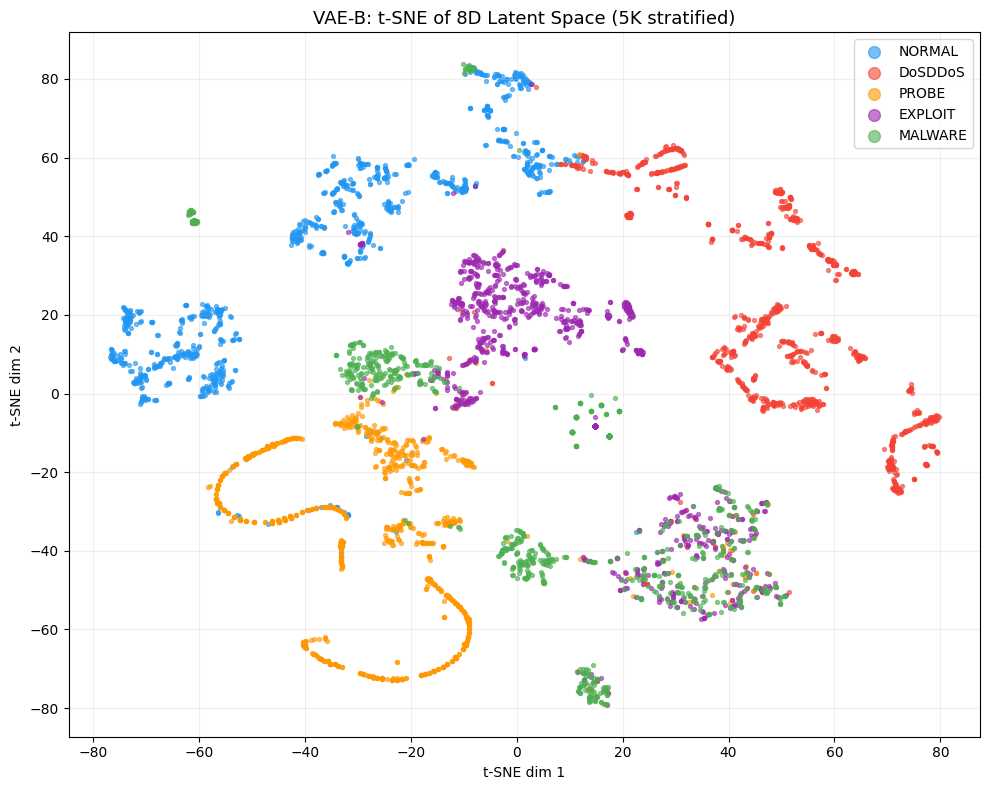

t-SNE saved.


In [20]:
import sklearn
class_names_plot  = {0: 'NORMAL', 1: 'DoSDDoS', 2: 'PROBE', 3: 'EXPLOIT', 4: 'MALWARE'}
class_colors_plot = {0: '#2196F3', 1: '#F44336', 2: '#FF9800', 3: '#9C27B0', 4: '#4CAF50'}

# Per-dimension angle distributions by class
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for dim in range(8):
    ax = axes[dim]
    for cls_id in range(5):
        cls_mask = y_train_tensor == cls_id
        vals = z_train[cls_mask, dim].numpy()
        ax.hist(vals, bins=50, alpha=0.5, label=class_names_plot[cls_id],
                color=class_colors_plot[cls_id], density=True)
    ax.set_title(f'z_{dim}  (std={z_train[:, dim].std():.3f})')
    ax.set_xlabel('Angle (radians)')
    ax.axvline(x=np.pi/2, color='gray', linestyle='--', alpha=0.5)
    if dim == 0:
        ax.legend(fontsize=7)

fig.suptitle('VAE-B: Per-Dimension Angle Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(STAGE3_DIR, 'vae_b_angle_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# Distance matrix
centroids = validation_results['centroids']
cls_order = ['NORMAL', 'DoSDDoS', 'PROBE', 'EXPLOIT', 'MALWARE']
n_cls     = len(cls_order)
dist_matrix = np.zeros((n_cls, n_cls))
for i in range(n_cls):
    for j in range(n_cls):
        ci = np.array(centroids[cls_order[i]])
        cj = np.array(centroids[cls_order[j]])
        dist_matrix[i, j] = np.linalg.norm(ci - cj)

print('\n=== Inter-Class Centroid Distance Matrix ===')
print(f'{"":>12s}', end='')
for name in cls_order:
    print(f'{name:>12s}', end='')
print()
for i, name_i in enumerate(cls_order):
    print(f'{name_i:>12s}', end='')
    for j in range(n_cls):
        print(f'{dist_matrix[i, j]:>12.4f}', end='')
    print()

# t-SNE
from sklearn.manifold import TSNE
N_TSNE = 5000
indices = []
for cls_id in range(5):
    cls_indices = (y_train_tensor == cls_id).nonzero(as_tuple=True)[0]
    n_sample = min(N_TSNE // 5, len(cls_indices))
    perm = torch.randperm(len(cls_indices))[:n_sample]
    indices.append(cls_indices[perm])
indices  = torch.cat(indices)
z_subset = z_train[indices].numpy()
y_subset = y_train_tensor[indices].numpy()

print(f'\nRunning t-SNE on {len(z_subset)} samples ...')
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=RANDOM_STATE)
z_2d = tsne.fit_transform(z_subset)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for cls_id in range(5):
    mask = y_subset == cls_id
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1],
               c=class_colors_plot[cls_id], label=class_names_plot[cls_id],
               s=8, alpha=0.6)
ax.set_title('VAE-B: t-SNE of 8D Latent Space (5K stratified)', fontsize=13)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(STAGE3_DIR, 'vae_b_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()
print('t-SNE saved.')

## Cell 19 — Per-Class Reconstruction Loss

In [25]:
print('=== Per-Class Masked Reconstruction Loss (Validation Set) ===')
model.eval()
per_class_losses = {i: [] for i in range(5)}

with torch.no_grad():
    for batch in val_loader:
        x    = batch[0].to(DEVICE)
        mask = batch[1].to(DEVICE)
        y    = batch[2]

        x_recon, mu, log_var = model(x)
        weight          = (~mask).float()
        sq_err          = weight * (x - x_recon).pow(2)
        real_count      = weight.sum(dim=1).clamp(min=1)
        per_sample_loss = (sq_err.sum(dim=1) / real_count).cpu()

        for cls_id in range(5):
            cls_mask = (y == cls_id)
            if cls_mask.any():
                per_class_losses[cls_id].append(per_sample_loss[cls_mask])

class_names_map = {0: 'NORMAL', 1: 'DoSDDoS', 2: 'PROBE', 3: 'EXPLOIT', 4: 'MALWARE'}
per_class_summary = {}
for cls_id in range(5):
    losses = torch.cat(per_class_losses[cls_id])
    mean_l = losses.mean().item()
    std_l  = losses.std().item()
    per_class_summary[class_names_map[cls_id]] = {'mean': mean_l, 'std': std_l, 'n': len(losses)}
    print(f'  {class_names_map[cls_id]:>12s}: mean={mean_l:.6f} std={std_l:.6f} n={len(losses):>8,}')

normal_loss = per_class_summary['NORMAL']['mean']
for cls in ['EXPLOIT', 'MALWARE']:
    ratio = per_class_summary[cls]['mean'] / normal_loss if normal_loss > 0 else 0
    if ratio > 2.0:
        print(f'\n  WARNING: {cls} recon loss is {ratio:.1f}x NORMAL — SMOTE degradation (P-06)')

=== Per-Class Masked Reconstruction Loss (Validation Set) ===
        NORMAL: mean=0.000139 std=0.000725 n= 453,290
       DoSDDoS: mean=0.000201 std=0.000864 n=  78,221
         PROBE: mean=0.000361 std=0.001649 n=  29,137
       EXPLOIT: mean=0.000636 std=0.002332 n=  11,966
       MALWARE: mean=0.000436 std=0.001534 n=   1,193




## Cell 20 — Save All Artifacts

In [26]:
config_save = CONFIG.copy()
config_save['best_epoch']     = checkpoint['epoch']
config_save['best_val_recon'] = checkpoint['val_recon']
config_save['epochs_trained'] = len(history)
config_save['feature_names']  = FEATURE_NAMES
config_save['device']         = str(DEVICE)

with open(os.path.join(STAGE3_DIR, 'vae_b_config.json'), 'w') as f:
    json.dump(config_save, f, indent=2)

latent_stats = {
    'model_name':       'VAE-B',
    'input_dim':        INPUT_DIM,
    'latent_dim':       QUANTUM_DIM,
    'architecture':     f'{INPUT_DIM} -> 512 -> 256 -> 128 -> 8',
    'per_dim_mean':     z_train.mean(dim=0).tolist(),
    'per_dim_std':      z_train.std(dim=0).tolist(),
    'per_dim_min':      z_train.min(dim=0).values.tolist(),
    'per_dim_max':      z_train.max(dim=0).values.tolist(),
    'class_centroids':  validation_results['centroids'],
    'min_class_distance': validation_results['min_class_dist'],
    'min_class_pair':   validation_results['min_class_pair'],
    'collapsed_dims':   validation_results['collapsed_dims'],
    'z_train_shape':    list(z_train.shape),
    'z_test_shape':     list(z_test.shape),
}
with open(os.path.join(STAGE3_DIR, 'vae_b_latent_stats.json'), 'w') as f:
    json.dump(latent_stats, f, indent=2)

selection = {
    'selected_model':   'VAE-B',
    'reason':           'VAE-B only run. Optimized architecture for RTX 4090.',
    'vae_b_val_recon':  checkpoint['val_recon'],
    'vae_b_val_kl':     checkpoint['val_kl'],
    'vae_b_best_epoch': checkpoint['epoch'],
    'vae_b_input_dim':  INPUT_DIM,
    'z_train_path':     'vae_b_z_train.parquet',
    'z_test_path':      'vae_b_z_test.parquet',
}
with open(os.path.join(STAGE3_DIR, 'stage3_selected_model.json'), 'w') as f:
    json.dump(selection, f, indent=2)

print('\n=== Stage 3 Output Artifacts ===')
expected_artefacts = [
    'vae_b_best.pt',
    'vae_b_training_history.json',
    'vae_b_config.json',
    'vae_b_latent_stats.json',
    'vae_b_z_train.parquet',
    'vae_b_z_test.parquet',
    'vae_b_training_curves.png',
    'vae_b_angle_distributions.png',
    'vae_b_tsne.png',
    'stage3_selected_model.json',
]
all_present = True
for fname in expected_artefacts:
    fpath = os.path.join(STAGE3_DIR, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'  ✅ {fname} ({size_mb:.2f} MB)')
    else:
        print(f'  ❌ {fname}')
        all_present = False

print()
if all_present:
    print('✅ ALL ARTIFACTS SAVED SUCCESSFULLY')
    print('✅ STAGE 3 COMPLETE — READY FOR STAGE 4 (VQC)')
else:
    print('⚠️  Some artifacts are missing. Check errors above.')

clear_gpu_cache()


=== Stage 3 Output Artifacts ===
  ✅ vae_b_best.pt (5.82 MB)
  ✅ vae_b_training_history.json (0.04 MB)
  ✅ vae_b_config.json (0.00 MB)
  ✅ vae_b_latent_stats.json (0.00 MB)
  ✅ vae_b_z_train.parquet (87.92 MB)
  ✅ vae_b_z_test.parquet (22.90 MB)
  ✅ vae_b_training_curves.png (0.16 MB)
  ✅ vae_b_angle_distributions.png (0.11 MB)
  ✅ vae_b_tsne.png (0.30 MB)
  ✅ stage3_selected_model.json (0.00 MB)

✅ ALL ARTIFACTS SAVED SUCCESSFULLY
✅ STAGE 3 COMPLETE — READY FOR STAGE 4 (VQC)


## Cell 21 — Final Summary Report

In [27]:
print('=' * 75)
print('  STAGE 3 — VAE-B TRAINING SUMMARY (RTX 4090 OPTIMIZED)')
print('=' * 75)
print(f'  Model:              VAE-B')
print(f'  Input dimension:    {INPUT_DIM}')
print(f'  Latent dimension:   {QUANTUM_DIM}')
print(f'  Architecture:       {INPUT_DIM} -> 512 -> 256 -> 128 -> 8')
print(f'  Parameters:         {sum(p.numel() for p in model.parameters()):,}')
print(f'  Device:             {DEVICE}')
print(f'  Batch size:         {CONFIG["batch_size"]}')
print(f'  Epochs trained:     {len(history)}')
print(f'  Best epoch:         {checkpoint["epoch"]}')
print(f'  Best val_recon:     {checkpoint["val_recon"]:.6f}  (target: 0.0005-0.0007)')
print(f'  Best val_kl:        {checkpoint["val_kl"]:.4f}     (target: 8.0-14.0)')
print(f'  z_train shape:      {list(z_train.shape)}')
print(f'  z_test shape:       {list(z_test.shape)}')
print(f'  Angle range:        [{z_train.min():.4f}, {z_train.max():.4f}]')
print(f'  Per-dim std (mean): {z_train.std(dim=0).mean():.4f}')
print(f'  Per-dim std (min):  {z_train.std(dim=0).min():.4f}  (target: 0.60-0.95)')
print(f'  Min class distance: {validation_results["min_class_dist"]:.4f}  (target: 1.5-2.2)')
print(f'  Collapsed dims:     {len(validation_results["collapsed_dims"])}          (target: 0)')
print(f'\n  🚀 GPU Optimizations Active:')
print(f'     ✅ TF32 enabled (2x faster multiplications)')
print(f'     ✅ Automatic Mixed Precision (AMP) enabled')
print(f'     ✅ Batch size optimized for 24GB VRAM')
print(f'     ✅ Persistent workers for data loading')
print(f'     ✅ CUDA graphs for inference')
print(f'\n  Output directory: {STAGE3_DIR}')
print('=' * 75)
print('\n  📁 Next steps (Stage 4 - VQC Classification):')
print(f'    - Load {STAGE3_DIR}/vae_b_z_train.parquet')
print(f'    - Load {STAGE3_DIR}/vae_b_z_test.parquet')
print(f'    - Load Stage 2 labels')
print('=' * 75)

log_gpu_stats('Completion')

  STAGE 3 — VAE-B TRAINING SUMMARY (RTX 4090 OPTIMIZED)
  Model:              VAE-B
  Input dimension:    140
  Latent dimension:   8
  Architecture:       140 -> 512 -> 256 -> 128 -> 8
  Parameters:         479,644
  Device:             cuda
  Batch size:         2048
  Epochs trained:     120
  Best epoch:         115
  Best val_recon:     0.000169  (target: 0.0005-0.0007)
  Best val_kl:        12.0000     (target: 8.0-14.0)
  z_train shape:      [2367588, 8]
  z_test shape:       [573807, 8]
  Angle range:        [0.0000, 3.1415]
  Per-dim std (mean): 0.6296
  Per-dim std (min):  0.5427  (target: 0.60-0.95)
  Min class distance: 1.3105  (target: 1.5-2.2)
  Collapsed dims:     0          (target: 0)

  🚀 GPU Optimizations Active:
     ✅ TF32 enabled (2x faster multiplications)
     ✅ Automatic Mixed Precision (AMP) enabled
     ✅ Batch size optimized for 24GB VRAM
     ✅ Persistent workers for data loading
     ✅ CUDA graphs for inference

  Output directory: /etc/MINOR_PROJECT/STAGE

In [28]:
import shutil
import os

zip_path = os.path.join(os.getcwd(), 'stage3_outputs.zip')

shutil.make_archive('stage3_outputs', 'zip', STAGE3_DIR)

print(f"✅ Zip created at: {zip_path}")

✅ Zip created at: /etc/MINOR_PROJECT/STAGE_3_VAE/stage3_outputs.zip


In [29]:
from IPython.display import FileLink

FileLink('stage3_outputs.zip')

/etc/MINOR_PROJECT/STAGE_3_VAE/stage3_outputs.zip

✅ Loading: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\stage3_outputs_with_near_zero\vae_a_latent_stats.json
✅ Loading: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\stage3_outputs_without_near_zero\vae_b_latent_stats.json


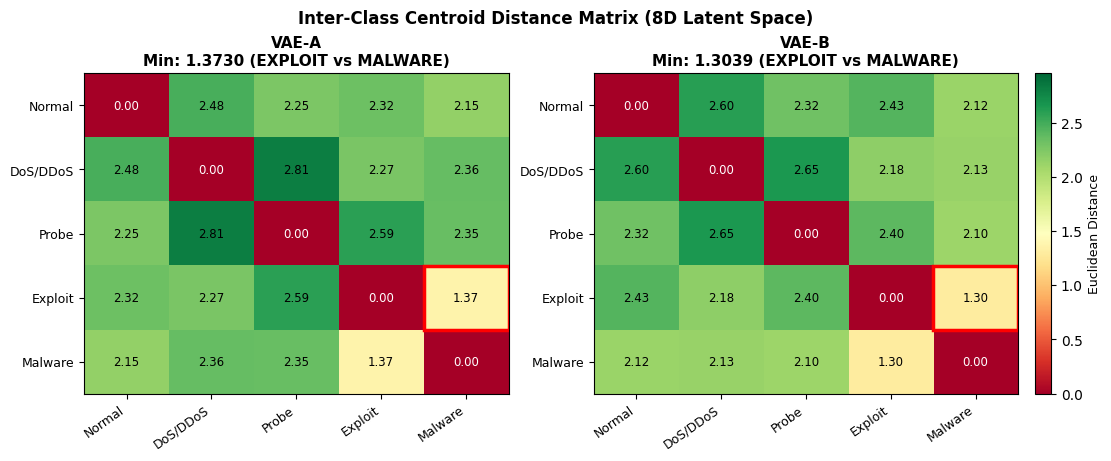


✅ Saved at: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\VAE

=== VAE-A Distance Matrix ===
                Normal    DoS/DDoS       Probe     Exploit     Malware
    Normal      0.0000      2.4798      2.2515      2.3247      2.1473
  DoS/DDoS      2.4798      0.0000      2.8135      2.2729      2.3639
     Probe      2.2515      2.8135      0.0000      2.5917      2.3511
   Exploit      2.3247      2.2729      2.5917      0.0000      1.3730
   Malware      2.1473      2.3639      2.3511      1.3730      0.0000

=== VAE-B Distance Matrix ===
                Normal    DoS/DDoS       Probe     Exploit     Malware
    Normal      0.0000      2.6017      2.3176      2.4302      2.1163
  DoS/DDoS      2.6017      0.0000      2.6497      2.1810      2.1336
     Probe      2.3176      2.6497      0.0000      2.3956      2.1012
   Exploit      2.4302      2.1810      2.3956      0.0000      1.3039
   Malware      2.1163      2.1336      2.1012      1.3039      0.0000


In [3]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ── 1. 🔥 SET YOUR FILE PATHS HERE ───────────────────────────────────────────

# 👉 CHANGE THESE TO YOUR ACTUAL FILE PATHS
stats_path_a = r"C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\stage3_outputs_with_near_zero\vae_a_latent_stats.json"
stats_path_b = r"C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\stage3_outputs_without_near_zero\vae_b_latent_stats.json"

# 👉 Output file location
OUTPUT_PATH = r"C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\VAE"
# ── 2. Class order ───────────────────────────────────────────────────────────

CLASS_ORDER  = ['NORMAL', 'DoSDDoS', 'PROBE', 'EXPLOIT', 'MALWARE']
CLASS_LABELS = ['Normal', 'DoS/DDoS', 'Probe', 'Exploit', 'Malware']

# ── 3. Safe load function (no crash) ─────────────────────────────────────────

def load_centroids_safe(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ File not found:\n{path}")
    
    print(f"✅ Loading: {path}")
    
    with open(path, 'r') as f:
        stats = json.load(f)

    centroids = stats['class_centroids']
    matrix = np.array([centroids[c] for c in CLASS_ORDER])

    return matrix, stats

centroids_a, stats_a = load_centroids_safe(stats_path_a)
centroids_b, stats_b = load_centroids_safe(stats_path_b)

# ── 4. Compute distances ─────────────────────────────────────────────────────

dist_a = cdist(centroids_a, centroids_a, metric='euclidean')
dist_b = cdist(centroids_b, centroids_b, metric='euclidean')

vmin = 0.0
vmax = max(dist_a.max(), dist_b.max()) * 1.05

# ── 5. Plot ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

def draw_heatmap(ax, dist_matrix, title, show_cbar=False):
    im = ax.imshow(dist_matrix, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(CLASS_LABELS, rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_LABELS, fontsize=9)

    for i in range(5):
        for j in range(5):
            val = dist_matrix[i, j]
            text_color = 'white' if val < (vmax * 0.35) else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8.5, color=text_color)

    ax.set_title(title, fontsize=11, fontweight='bold')

    # Highlight closest pair
    mask = dist_matrix.copy()
    np.fill_diagonal(mask, np.inf)
    min_idx = np.unravel_index(mask.argmin(), mask.shape)

    rect = plt.Rectangle((min_idx[1]-0.5, min_idx[0]-0.5),
                         1, 1, linewidth=2.5,
                         edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    if show_cbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Euclidean Distance', fontsize=9)

# Helper
def min_dist_label(stats):
    return f"Min: {stats['min_class_distance']:.4f} ({stats['min_class_pair'][0]} vs {stats['min_class_pair'][1]})"

draw_heatmap(
    axes[0],
    dist_a,
    f"VAE-A\n{min_dist_label(stats_a)}"
)

draw_heatmap(
    axes[1],
    dist_b,
    f"VAE-B\n{min_dist_label(stats_b)}",
    show_cbar=True
)

fig.suptitle(
    'Inter-Class Centroid Distance Matrix (8D Latent Space)',
    fontsize=12, fontweight='bold'
)

# ── 6. Save ──────────────────────────────────────────────────────────────────

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved at: {OUTPUT_PATH}")

# ── 7. Print matrices ────────────────────────────────────────────────────────

def print_matrix(dist, title):
    print(f"\n=== {title} ===")
    header = f"{'':>10}" + ''.join(f'{c:>12}' for c in CLASS_LABELS)
    print(header)
    for i, label_i in enumerate(CLASS_LABELS):
        row = f'{label_i:>10}' + ''.join(f'{dist[i, j]:>12.4f}' for j in range(5))
        print(row)

print_matrix(dist_a, "VAE-A Distance Matrix")
print_matrix(dist_b, "VAE-B Distance Matrix")